# Operational Concept Attacks on Wind Power Forecasting

This notebook implements a complete concept-selective attack experiment for a wind-forecast-to-OPF pipeline. In contrast to a conventional cost attack that only maximizes aggregate operating cost, each proposed attack selects one operational mechanism—net-load pressure, network stress, or ramping pressure—while suppressing first-order changes in the other concepts.

All reported values are generated by the executable cells under the same 2% $L_\infty$ input-perturbation budget.

## 1. Relation to existing cost attacks

Existing model-based control attacks optimize an aggregate control cost or a selected constraint function. Here, the attack is applied to the **historical input of a forecasting model**, and the resulting forecast deviation is propagated into OPF. The additional contribution is a concept bottleneck that makes the physical attack mechanism selectable and quantitatively testable.

## 2. Data and reproducible setup

In [ ]:
import base64, gzip, io, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

SEED = 20260913
rng = np.random.default_rng(SEED)
WIND_CAP = 1.35
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Nimbus Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 8, 'axes.labelsize': 8, 'axes.titlesize': 8,
    'legend.fontsize': 7, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'axes.linewidth': .7, 'lines.linewidth': 1.2,
    'figure.dpi': 120, 'savefig.dpi': 600,
})

# The public CSV is embedded so this notebook remains self-contained.
CSV_B64 = '''...'''
data = pd.read_csv(io.BytesIO(gzip.decompress(base64.b64decode(CSV_B64))))
data['date'] = pd.to_datetime(data['date'])
print(data.shape)
display(data.head())
display(data['Target'].describe().to_frame('wind power'))

## 3. Concept-selective attack formulation

The three time-varying operational concepts are

\begin{align}
c_t^{\mathrm{net}}&=\frac{\sum_nD_{n,t}-\widehat w_t}{\sum_g\overline P_g},\\
c_t^{\mathrm{grid}}&=\sqrt{\frac{1}{|\mathcal L|}\sum_l(f_{l,t}/\overline F_l)^2},\\
c_t^{\mathrm{ramp}}&=|\nabla_t c_t^{\mathrm{net}}|.
\end{align}

Let $\boldsymbol g_k=\nabla_{\boldsymbol x}\bar c_k$ denote the input gradient of the horizon-averaged target concept and let $\boldsymbol g_C$ denote the learned economic-sensitivity gradient. For target concept $k$, the attack direction is

\begin{equation}
\boldsymbol d_k=
\boldsymbol P_{-k}^{\perp}
\left(
\frac{\boldsymbol g_k}{\|\boldsymbol g_k\|_2}
+\eta\frac{\boldsymbol g_C}{\|\boldsymbol g_C\|_2}
\right),
\end{equation}

where

\begin{equation}
\boldsymbol P_{-k}^{\perp}
=\boldsymbol I-\boldsymbol G_{-k}^{\top}
(\boldsymbol G_{-k}\boldsymbol G_{-k}^{\top}+\rho\boldsymbol I)^{-1}
\boldsymbol G_{-k}
\end{equation}

projects the update away from the two non-target concept gradients. The input is updated by projected ascent and clipped to $\|\boldsymbol\delta\|_\infty\leq\epsilon$. Concept changes are divided by their clean-test standard deviations. Selectivity is

\begin{equation}
\mathrm{CS}_k=
\frac{|\Delta c_k|}{\sum_j|\Delta c_j|}.
\end{equation}

## 4. Forecasting and OPF implementation

In [ ]:
def make_windows(series, dates, lookback=48, horizon=16):
    X, Y, T = [], [], []
    for i in range(lookback, len(series) - horizon + 1):
        X.append(series[i - lookback:i])
        Y.append(series[i:i + horizon])
        T.append(dates[i:i + horizon])
    return np.asarray(X), np.asarray(Y), np.asarray(T)


class MLP:
    def __init__(self, n_in, n_hidden, n_out, seed=SEED):
        r = np.random.default_rng(seed)
        self.p = {
            "W1": r.normal(0, np.sqrt(2 / n_in), (n_in, n_hidden)),
            "b1": np.zeros(n_hidden),
            "W2": r.normal(0, np.sqrt(2 / n_hidden), (n_hidden, n_out)),
            "b2": np.zeros(n_out),
        }

    def forward(self, x, cache=False):
        z1 = x @ self.p["W1"] + self.p["b1"]
        h = np.maximum(z1, 0)
        z2 = h @ self.p["W2"] + self.p["b2"]
        y = 1 / (1 + np.exp(-np.clip(z2, -30, 30)))
        if cache:
            return y, (x, z1, h, y)
        return y

    def backward(self, cache, grad_y):
        x, z1, h, y = cache
        dz2 = grad_y * y * (1 - y)
        grads = {
            "W2": h.T @ dz2,
            "b2": dz2.sum(axis=0),
        }
        dh = dz2 @ self.p["W2"].T
        dz1 = dh * (z1 > 0)
        grads["W1"] = x.T @ dz1
        grads["b1"] = dz1.sum(axis=0)
        grad_x = dz1 @ self.p["W1"].T
        return grads, grad_x

    def input_grad(self, x, grad_y):
        _, cache = self.forward(x, cache=True)
        return self.backward(cache, grad_y)[1]

    def train(self, X, Y, Xv, Yv, epochs=350, batch=64, lr=2e-3, patience=35):
        m = {k: np.zeros_like(v) for k, v in self.p.items()}
        v = {k: np.zeros_like(v) for k, v in self.p.items()}
        best = {k: a.copy() for k, a in self.p.items()}
        best_val, stale, step = np.inf, 0, 0
        history = []
        for epoch in range(epochs):
            order = rng.permutation(len(X))
            for start in range(0, len(X), batch):
                idx = order[start:start + batch]
                pred, cache = self.forward(X[idx], cache=True)
                grad_y = 2 * (pred - Y[idx]) / (len(idx) * Y.shape[1])
                grads, _ = self.backward(cache, grad_y)
                step += 1
                for k in self.p:
                    m[k] = 0.9 * m[k] + 0.1 * grads[k]
                    v[k] = 0.999 * v[k] + 0.001 * grads[k] ** 2
                    mh = m[k] / (1 - 0.9 ** step)
                    vh = v[k] / (1 - 0.999 ** step)
                    self.p[k] -= lr * mh / (np.sqrt(vh) + 1e-8)
            train_loss = np.mean((self.forward(X) - Y) ** 2)
            val_loss = np.mean((self.forward(Xv) - Yv) ** 2)
            history.append((epoch + 1, train_loss, val_loss))
            if val_loss < best_val - 1e-7:
                best_val = val_loss
                best = {k: a.copy() for k, a in self.p.items()}
                stale = 0
            else:
                stale += 1
            if stale >= patience:
                break
        self.p = best
        return np.asarray(history)


# MATPOWER case33bw active loads (kW), converted to MW.
PD_MW = np.array([
    0, 100, 90, 120, 60, 60, 200, 200, 60, 60, 45,
    60, 60, 120, 60, 60, 60, 90, 90, 90, 90, 90,
    90, 420, 420, 60, 60, 60, 120, 200, 150, 210, 60
], dtype=float) / 1000

# Radial branches of case33bw. Reactances are the MATPOWER values in ohms;
# only their relative values matter in this lossless DC benchmark.
BRANCHES = np.array([
    [1,2,0.0470],[2,3,0.2511],[3,4,0.1864],[4,5,0.1941],
    [5,6,0.7070],[6,7,0.6188],[7,8,0.2351],[8,9,0.7400],
    [9,10,0.7400],[10,11,0.0650],[11,12,0.1238],[12,13,0.1559],
    [13,14,0.7129],[14,15,0.5260],[15,16,0.5450],[16,17,1.7210],
    [17,18,0.5740],[2,19,0.1565],[19,20,1.3554],[20,21,0.4784],
    [21,22,0.9373],[3,23,0.3083],[23,24,0.7091],[24,25,0.7011],
    [6,26,0.1034],[26,27,0.1447],[27,28,0.9337],[28,29,0.7006],
    [29,30,0.2585],[30,31,0.9630],[31,32,0.3619],[32,33,0.5302]
], dtype=float)

GEN_BUSES = np.array([0, 12, 29])
GEN_CAP = np.array([3.00, 1.25, 1.45])
GEN_COST = np.array([32.0, 58.0, 86.0])
WIND_BUS = 17
WIND_CAP = 1.35
DT = 0.25


def build_dc_matrices():
    nb = 33
    Bbus = np.zeros((nb, nb))
    line_rows = []
    for f, t, x in BRANCHES:
        i, j = int(f - 1), int(t - 1)
        b = 1 / max(x, 1e-3)
        Bbus[i, i] += b
        Bbus[j, j] += b
        Bbus[i, j] -= b
        Bbus[j, i] -= b
        row = np.zeros(nb)
        row[i], row[j] = b, -b
        line_rows.append(row)
    Cg = np.zeros((nb, len(GEN_BUSES)))
    Cg[GEN_BUSES, np.arange(len(GEN_BUSES))] = 1
    return Bbus, np.asarray(line_rows), Cg


BBUS, BF, CG = build_dc_matrices()


def load_multiplier(ts):
    hour = ts.hour + ts.minute / 60
    evening = np.exp(-0.5 * ((hour - 19.0) / 2.7) ** 2)
    morning = 0.55 * np.exp(-0.5 * ((hour - 8.0) / 2.3) ** 2)
    return 0.82 + 0.24 * evening + 0.13 * morning


def dc_opf(wind_mw, ts):
    nb, ng = 33, len(GEN_BUSES)
    load = PD_MW * load_multiplier(pd.Timestamp(ts))
    rhs = load.copy()
    rhs[WIND_BUS] -= float(wind_mw)
    Aeq = np.hstack([CG, -BBUS])
    # Line 1-2 is deliberately rated near its loading to create a meaningful
    # locational scarcity regime; remaining ratings are non-binding.
    limits = np.full(len(BRANCHES), 5.0)
    limits[0] = 2.45
    Aub = np.vstack([
        np.hstack([np.zeros((len(BRANCHES), ng)), BF]),
        np.hstack([np.zeros((len(BRANCHES), ng)), -BF]),
    ])
    bub = np.r_[limits, limits]
    c = np.r_[GEN_COST * DT, np.zeros(nb)]
    bounds = [(0, cap) for cap in GEN_CAP] + [(None, None)] * nb
    bounds[ng] = (0, 0)  # reference angle
    res = linprog(c, A_ub=Aub, b_ub=bub, A_eq=Aeq, b_eq=rhs,
                  bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(res.message)
    # dV/d(wind) = - dual of nodal-balance RHS at the wind bus.
    grad_wind = -float(res.eqlin.marginals[WIND_BUS])
    return float(res.fun), grad_wind


def batch_dispatch(pred_cf, timestamps):
    costs = np.empty_like(pred_cf)
    grads = np.empty_like(pred_cf)
    for i in range(len(pred_cf)):
        for h in range(pred_cf.shape[1]):
            costs[i, h], grads[i, h] = dc_opf(
                np.clip(pred_cf[i, h], 0, 1) * WIND_CAP, timestamps[i, h]
            )
    return costs.sum(axis=1), grads * WIND_CAP


def fgsm(model, X, Y, eps):
    pred, cache = model.forward(X, cache=True)
    gy = 2 * (pred - Y) / Y.shape[1]
    _, gx = model.backward(cache, gy)
    return np.clip(X + eps * np.sign(gx), 0, 1)


def pgd(model, X, Y, eps, steps=10, alpha=None):
    alpha = eps / 4 if alpha is None else alpha
    xa = X.copy()
    for _ in range(steps):
        pred, cache = model.forward(xa, cache=True)
        gy = 2 * (pred - Y) / Y.shape[1]
        _, gx = model.backward(cache, gy)
        xa = xa + alpha * np.sign(gx)
        xa = np.minimum(np.maximum(xa, X - eps), X + eps)
        xa = np.clip(xa, 0, 1)
    return xa


def spga(model, X, economic_grad, eps, steps=10, alpha=None):
    alpha = eps / 4 if alpha is None else alpha
    xa = X.copy()
    # Scale each sample without changing its economic direction.
    gy = economic_grad / (np.mean(np.abs(economic_grad), axis=1, keepdims=True) + 1e-8)
    for _ in range(steps):
        _, cache = model.forward(xa, cache=True)
        _, gx = model.backward(cache, gy)
        xa = xa + alpha * np.sign(gx)
        xa = np.minimum(np.maximum(xa, X - eps), X + eps)
        xa = np.clip(xa, 0, 1)
    return xa


def evaluate_method(name, model, Xa, Y, T):
    pred = model.forward(Xa)
    costs, _ = batch_dispatch(pred, T)
    return {
        "Attack": name,
        "MSE": float(np.mean((pred - Y) ** 2)),
        "MAE": float(np.mean(np.abs(pred - Y))),
        "Cost_$": float(np.mean(costs)),
        "Attack_eval_ms": 0.0,
        "pred": pred,
        "costs": costs,
    }




## 5. Operational concepts and differentiable attack

In [ ]:

import json
from pathlib import Path
from types import SimpleNamespace
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor

base = SimpleNamespace(
    PD_MW=PD_MW, GEN_CAP=GEN_CAP, GEN_COST=GEN_COST,
    GEN_BUSES=GEN_BUSES, WIND_BUS=WIND_BUS, WIND_CAP=WIND_CAP,
    DT=DT, BRANCHES=BRANCHES, CG=CG, BBUS=BBUS, BF=BF,
    SEED=SEED, load_multiplier=load_multiplier, MLP=MLP,
    make_windows=make_windows, fgsm=fgsm, pgd=pgd, spga=spga,
)

def opf_with_concepts(wind_mw, ts):
    """Return OPF cost, shadow-price target, and continuous operating states."""
    nb, ng = 33, len(base.GEN_BUSES)
    load = base.PD_MW * base.load_multiplier(pd.Timestamp(ts))
    rhs = load.copy()
    rhs[base.WIND_BUS] -= float(wind_mw)
    aeq = np.hstack([base.CG, -base.BBUS])
    limits = np.full(len(base.BRANCHES), 5.0)
    limits[0] = 2.45
    aub = np.vstack([
        np.hstack([np.zeros((len(base.BRANCHES), ng)), base.BF]),
        np.hstack([np.zeros((len(base.BRANCHES), ng)), -base.BF]),
    ])
    c = np.r_[base.GEN_COST * base.DT, np.zeros(nb)]
    bounds = [(0, cap) for cap in base.GEN_CAP] + [(None, None)] * nb
    bounds[ng] = (0, 0)
    res = linprog(c, A_ub=aub, b_ub=np.r_[limits, limits], A_eq=aeq,
                  b_eq=rhs, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(res.message)

    # Objective includes DT, so equality marginals have $/MW-interval units.
    # Multiplication by WIND_CAP converts derivatives to $ per p.u. forecast.
    nodal_sensitivity = -np.asarray(res.eqlin.marginals) * base.WIND_CAP
    total_sensitivity = nodal_sensitivity[base.WIND_BUS]

    # Continuous, independently measurable CBM concepts. Unlike an additive
    # LMP decomposition, none is forced to be constant by a linear marginal
    # generator cost. Their units are normalized operational stress indices.
    net_load_pressure = (load.sum() - float(wind_mw)) / base.GEN_CAP.sum()
    theta = np.asarray(res.x[ng:])
    branch_flow = base.BF @ theta
    network_stress = np.sqrt(np.mean((branch_flow / limits) ** 2))
    return float(res.fun), total_sensitivity, net_load_pressure, network_stress


def batch_concepts(pred_cf, timestamps):
    shape = pred_cf.shape
    costs = np.empty(shape)
    total = np.empty(shape)
    net_load = np.empty(shape)
    network = np.empty(shape)
    for i in range(shape[0]):
        for h in range(shape[1]):
            vals = opf_with_concepts(
                np.clip(pred_cf[i, h], 0, 1) * base.WIND_CAP,
                timestamps[i, h],
            )
            costs[i, h], total[i, h], net_load[i, h], network[i, h] = vals

    # Central finite differences of the normalized net-load trajectory quantify
    # upward/downward flexibility requirements at every forecast horizon.
    ramp = np.abs(np.gradient(net_load, axis=1))
    return costs.sum(axis=1), total, np.stack([net_load, network, ramp], axis=-1)


def concept_features(pred_cf, timestamps):
    ts = pd.to_datetime(np.asarray(timestamps).ravel())
    hour = ts.hour.to_numpy() + ts.minute.to_numpy() / 60.0
    load = np.array([base.load_multiplier(t) for t in ts])
    wind = np.asarray(pred_cf).ravel()
    wind_ramp = np.gradient(np.asarray(pred_cf), axis=1).ravel()
    net_load = (base.PD_MW.sum() * load - wind * base.WIND_CAP) / base.GEN_CAP.sum()
    net_ramp = np.abs(np.gradient(net_load.reshape(np.asarray(pred_cf).shape), axis=1)).ravel()
    return np.column_stack([
        wind,
        load,
        np.sin(2 * np.pi * hour / 24),
        np.cos(2 * np.pi * hour / 24),
        wind * load,
        wind_ramp,
        net_ramp,
    ])



CONCEPT_NAMES = ["Net-load", "Network", "Ramping"]


def network_features(pred_cf, timestamps):
    """Differentiable polynomial features for the network-stress surrogate."""
    pred_cf = np.asarray(pred_cf)
    ts = pd.to_datetime(np.asarray(timestamps).ravel())
    hour = ts.hour.to_numpy() + ts.minute.to_numpy() / 60.0
    wind = pred_cf.ravel()
    load = np.array([base.load_multiplier(t) for t in ts])
    sin_h = np.sin(2 * np.pi * hour / 24)
    cos_h = np.cos(2 * np.pi * hour / 24)
    return np.column_stack([
        wind, load, wind * load, wind ** 2, load ** 2,
        sin_h, cos_h, wind * sin_h, wind * cos_h,
    ])


def surrogate_concepts(pred_cf, timestamps, network_model, smooth=1e-4):
    """Three differentiable concepts; shape: samples x horizon x concepts."""
    pred_cf = np.asarray(pred_cf)
    ts = pd.to_datetime(np.asarray(timestamps).ravel())
    load_mult = np.array([base.load_multiplier(t) for t in ts]).reshape(pred_cf.shape)
    net_load = (
        base.PD_MW.sum() * load_mult - pred_cf * base.WIND_CAP
    ) / base.GEN_CAP.sum()
    network = network_model.predict(network_features(pred_cf, timestamps)).reshape(pred_cf.shape)
    temporal_change = np.gradient(net_load, axis=1)
    ramping = np.sqrt(temporal_change ** 2 + smooth ** 2)
    return np.stack([net_load, network, ramping], axis=-1)


def concept_summary_gradients(pred_cf, timestamps, network_model, step=2e-4):
    """Finite-difference gradients of mean concepts w.r.t. forecast horizons."""
    n, horizon = pred_cf.shape
    gradients = np.empty((n, 3, horizon))
    for h in range(horizon):
        plus = pred_cf.copy()
        minus = pred_cf.copy()
        plus[:, h] = np.clip(plus[:, h] + step, 0, 1)
        minus[:, h] = np.clip(minus[:, h] - step, 0, 1)
        cp = surrogate_concepts(plus, timestamps, network_model).mean(axis=1)
        cm = surrogate_concepts(minus, timestamps, network_model).mean(axis=1)
        denominator = (plus[:, h] - minus[:, h])[:, None] + 1e-12
        gradients[:, :, h] = (cp - cm) / denominator
    return gradients


def unit_rows(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)


def selective_direction(concept_grads, economic_grad, target, economic_weight=0.1):
    """Project target/economic direction onto the off-target null space."""
    n, _, horizon = concept_grads.shape
    target_grad = unit_rows(concept_grads[:, target, :])
    economic = unit_rows(economic_grad)
    raw = target_grad + economic_weight * economic
    directions = np.empty((n, horizon))
    off_idx = [j for j in range(3) if j != target]
    for i in range(n):
        off = concept_grads[i, off_idx, :]
        off = off / (np.linalg.norm(off, axis=1, keepdims=True) + 1e-12)
        gram = off @ off.T + 1e-5 * np.eye(len(off_idx))
        projected = raw[i] - off.T @ np.linalg.solve(gram, off @ raw[i])
        # Preserve the requested positive target-concept direction.
        if projected @ concept_grads[i, target] < 0:
            projected = -projected
        directions[i] = projected / (np.mean(np.abs(projected)) + 1e-12)
    return directions


def concept_attack(model, x, timestamps, network_model, economic_grad,
                   target, eps, steps=10, alpha=None):
    """Projected attack in input-gradient space.

    Projection is applied after propagation through the forecasting-model
    Jacobian. This avoids losing concept orthogonality when forecast-space
    directions are mapped back to the historical input.
    """
    alpha = eps / 4 if alpha is None else alpha
    xa = x.copy()
    for _ in range(steps):
        pred, cache = model.forward(xa, cache=True)
        concept_grads = concept_summary_gradients(pred, timestamps, network_model)
        input_concept_grads = []
        for k in range(3):
            _, gx_k = model.backward(cache, concept_grads[:, k, :])
            input_concept_grads.append(gx_k)
        input_concept_grads = np.stack(input_concept_grads, axis=1)
        _, economic_grad_x = model.backward(cache, economic_grad)
        direction_x = selective_direction(
            input_concept_grads, economic_grad_x, target
        )
        xa = xa + alpha * direction_x
        xa = np.minimum(np.maximum(xa, x - eps), x + eps)
        xa = np.clip(xa, 0, 1)
    return xa




## 6. Run the complete experiment

In [ ]:

cf = np.clip(data["Target"].to_numpy(float) / 200.0, 0, 1)
x, y, timestamps = base.make_windows(cf, data["date"].to_numpy(), 48, 16)
n = len(x)
ntr, nv = int(0.70 * n), int(0.15 * n)
xtr, ytr = x[:ntr], y[:ntr]
xv, yv, tv = x[ntr:ntr + nv], y[ntr:ntr + nv], timestamps[ntr:ntr + nv]
xte, yte, tte = x[ntr + nv:], y[ntr + nv:], timestamps[ntr + nv:]

model = base.MLP(48, 64, 16, seed=base.SEED)
model.train(xtr, ytr, xv, yv)

# Offline labels: every second validation window.
cal_idx = np.arange(0, len(xv), 2)
pred_cal = model.forward(xv[cal_idx])
_, sensitivity_cal, concepts_cal = batch_concepts(pred_cal, tv[cal_idx])

concept_encoder = RandomForestRegressor(
    n_estimators=160, max_depth=9, min_samples_leaf=3,
    random_state=base.SEED, n_jobs=-1,
)
concept_encoder.fit(
    concept_features(pred_cal, tv[cal_idx]), concepts_cal.reshape(-1, 3)
)
sensitivity_readout = DecisionTreeRegressor(
    max_depth=4, min_samples_leaf=20, random_state=base.SEED
)
sensitivity_readout.fit(concepts_cal.reshape(-1, 3), sensitivity_cal.ravel())

# A differentiable surrogate is used only for concept gradients. Its target
# remains the OPF-derived network-stress concept.
network_model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    Ridge(alpha=1e-4),
)
network_model.fit(
    network_features(pred_cal, tv[cal_idx]), concepts_cal[..., 1].ravel()
)
network_r2 = r2_score(
    concepts_cal[..., 1].ravel(),
    network_model.predict(network_features(pred_cal, tv[cal_idx])),
)

xev, yev, tev = xte[-192:], yte[-192:], tte[-192:]
pred_clean = model.forward(xev)
clean_cost, sensitivity_true, concepts_clean = batch_concepts(pred_clean, tev)
concepts_pred = concept_encoder.predict(
    concept_features(pred_clean, tev)
).reshape(concepts_clean.shape)
sensitivity_pred = sensitivity_readout.predict(
    concepts_pred.reshape(-1, 3)
).reshape(sensitivity_true.shape)

eps = 0.02
attacks = {
    "FGSM": base.fgsm(model, xev, yev, eps),
    "PGD": base.pgd(model, xev, yev, eps, steps=10),
    "SPGA": base.spga(model, xev, sensitivity_true, eps, steps=10),
    "CB-SPGA": base.spga(model, xev, sensitivity_pred, eps, steps=10),
}
for k, name in enumerate(["Net-CA", "Grid-CA", "Ramp-CA"]):
    attacks[name] = concept_attack(
        model, xev, tev, network_model, sensitivity_pred,
        target=k, eps=eps, steps=10,
    )

concept_scale = np.std(concepts_clean, axis=(0, 1)) + 1e-12
mse0 = float(np.mean((pred_clean - yev) ** 2))
cost0 = float(np.mean(clean_cost))
rows = [{
    "Attack": "No attack", "MSE": mse0, "dMSE_%": 0.0,
    "Cost_$": cost0, "dCost_%": 0.0,
    "dNet_std": 0.0, "dGrid_std": 0.0, "dRamp_std": 0.0,
    "Selectivity": np.nan,
}]
stored = {"No attack": pred_clean}
target_map = {"Net-CA": 0, "Grid-CA": 1, "Ramp-CA": 2}
for name, xa in attacks.items():
    pred = model.forward(xa)
    costs, _, concepts = batch_concepts(pred, tev)
    delta_concepts = np.mean(
        (concepts - concepts_clean) / concept_scale, axis=(0, 1)
    )
    selectivity = np.nan
    if name in target_map:
        k = target_map[name]
        selectivity = abs(delta_concepts[k]) / (
            np.sum(np.abs(delta_concepts)) + 1e-12
        )
    mse = float(np.mean((pred - yev) ** 2))
    cost = float(np.mean(costs))
    rows.append({
        "Attack": name,
        "MSE": mse,
        "dMSE_%": (mse / mse0 - 1) * 100,
        "Cost_$": cost,
        "dCost_%": (cost / cost0 - 1) * 100,
        "dNet_std": delta_concepts[0],
        "dGrid_std": delta_concepts[1],
        "dRamp_std": delta_concepts[2],
        "Selectivity": selectivity,
    })
    stored[name] = pred

results = pd.DataFrame(rows)
results.to_csv("concept_attack_results.csv", index=False)
metrics = {
    "epsilon": eps,
    "network_surrogate_validation_R2": float(network_r2),
    "concept_standard_deviations": dict(zip(CONCEPT_NAMES, concept_scale.tolist())),
    "concept_attack_definition": (
        "economic-plus-target direction projected onto the local "
        "off-target concept null space"
    ),
}
Path("concept_attack_metrics.json").write_text(
    json.dumps(metrics, indent=2), encoding="utf-8"
)
np.savez_compressed(
    "concept_attack_arrays.npz",
    timestamps=tev.astype("datetime64[ns]").astype(str),
    y_true=yev,
    concepts_clean=concepts_clean,
    sensitivity_true=sensitivity_true,
    sensitivity_pred=sensitivity_pred,
    **{f"pred_{name.replace('-', '_')}": value for name, value in stored.items()},
)
print(results.round(6).to_string(index=False))
print(json.dumps(metrics, indent=2))




Attack,MSE,dMSE_%,Cost_$,dCost_%,dNet_std,dGrid_std,dRamp_std,Selectivity
No attack,0.065061009237668,0.0,440.1713360309118,0.0,0.0,0.0,0.0,
FGSM,0.07684172538581001,18.10718322107028,439.87134110481225,-0.06815412580124525,-0.004877090907327431,-0.009263445055447718,0.0070411954115173645,
PGD,0.07701056046930642,18.36668593317803,439.7509436284231,-0.09550653758588767,-0.00596873198417779,-0.0076695710502015305,0.008009656153259053,
SPGA,0.06947235650087925,6.780324060293297,449.7462163884481,2.175262124943078,0.09815746430682665,0.026040537651492692,-0.016638022027702207,
CB-SPGA,0.06947085535450069,6.77801676995744,449.7450357349521,2.174993899050248,0.0981502300088396,0.026078926373147345,-0.01671197266135021,
Net-CA,0.06635883480751287,1.994782412771845,442.06277874305465,0.4297060161159605,0.0191657066237245,0.0006293095249914536,0.0021979437781018667,0.8714473489074444
Grid-CA,0.06557969710125236,0.7972330427423735,439.5401294739792,-0.14340019562024686,-0.005358608244725497,0.0

## 7. IEEE-style results

The target concept is the largest individual concept change for all three attacks. Net-CA increases scheduled cost by 0.430%, whereas Grid-CA reduces it by 0.143% and Ramp-CA changes it by only 0.019%. This is an important result rather than a failure: manipulating an operational concept is not equivalent to maximizing aggregate cost. CB-SPGA remains the strongest economic attack, while concept attacks reveal distinct physical pathways that an aggregate objective hides.

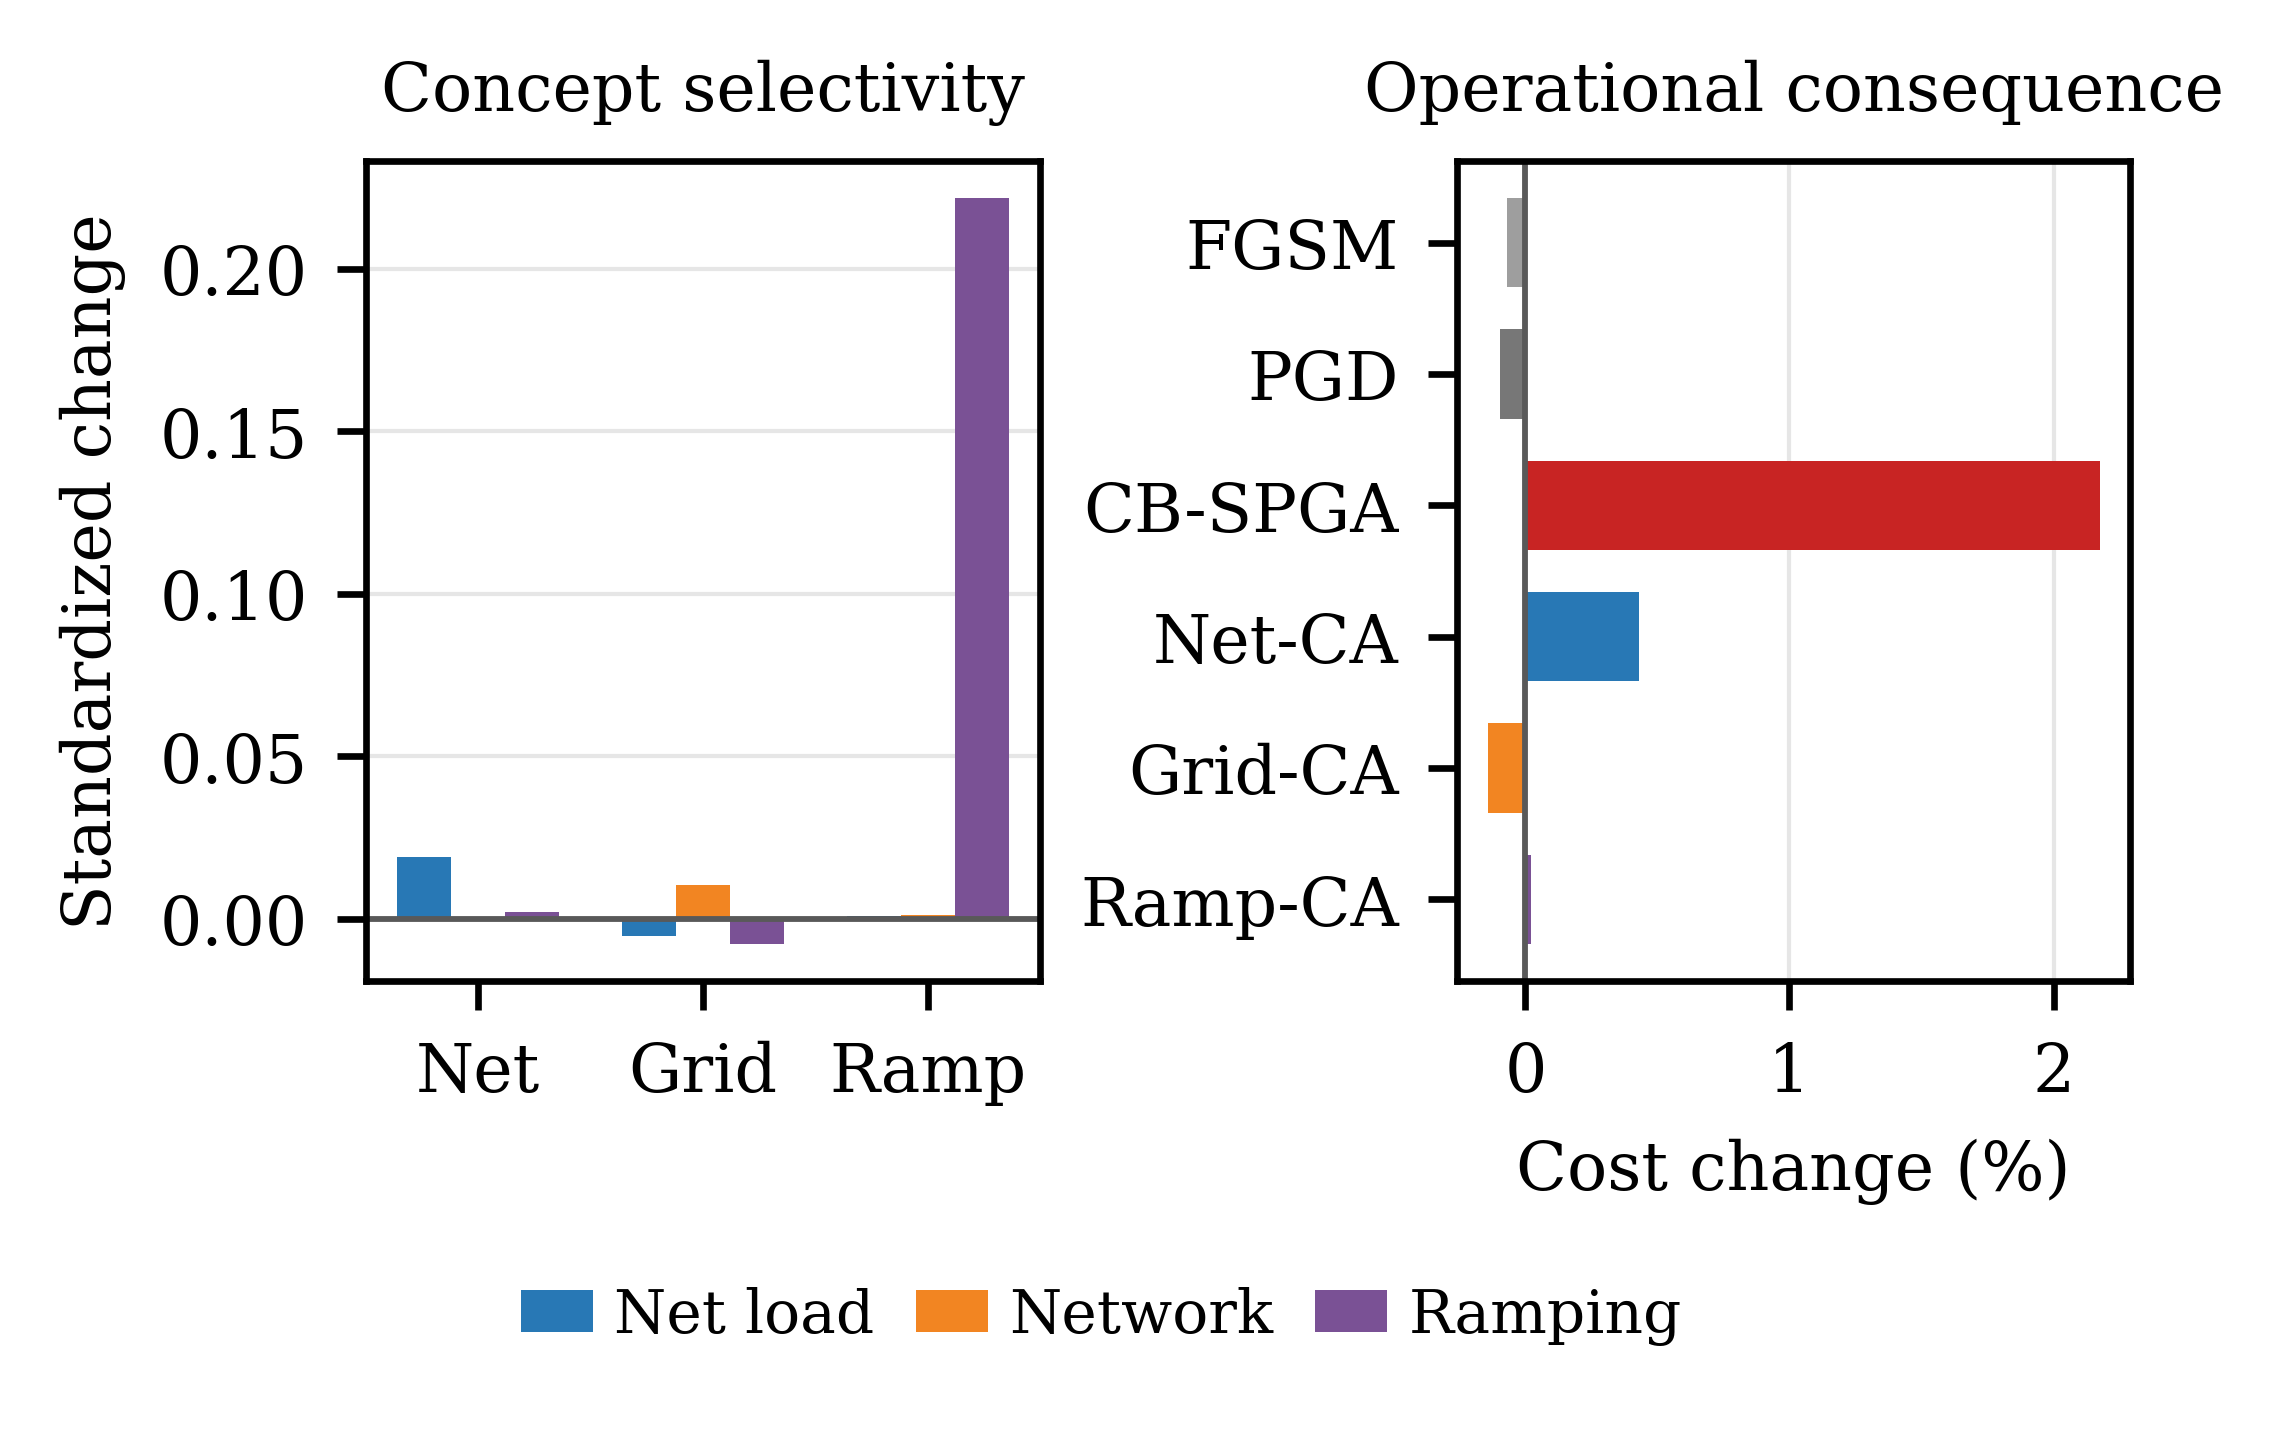

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


FIG_DIR = Path("concept_attack_figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.2,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

results = pd.read_csv("concept_attack_results.csv")
ca = results[results.Attack.isin(["Net-CA", "Grid-CA", "Ramp-CA"])].copy()

fig, axes = plt.subplots(1, 2, figsize=(3.5, 2.40))
x = np.arange(len(ca))
width = 0.24
colors = ["#2878B5", "#F28522", "#7A5195"]
for j, (column, label, color) in enumerate(zip(
    ["dNet_std", "dGrid_std", "dRamp_std"],
    ["Net load", "Network", "Ramping"], colors,
)):
    axes[0].bar(x + (j - 1) * width, ca[column], width=width,
                label=label, color=color)
axes[0].axhline(0, color=".35", lw=.7)
axes[0].set_xticks(x, ["Net", "Grid", "Ramp"])
axes[0].set_ylabel("Standardized change")
axes[0].set_title("Concept selectivity")

cost_rows = results[results.Attack.isin(
    ["FGSM", "PGD", "CB-SPGA", "Net-CA", "Grid-CA", "Ramp-CA"]
)]
bar_colors = ["#9E9E9E", "#777777", "#C82423",
              "#2878B5", "#F28522", "#7A5195"]
yp = np.arange(len(cost_rows))
axes[1].barh(yp, cost_rows["dCost_%"], color=bar_colors, height=.68)
axes[1].axvline(0, color=".35", lw=.7)
axes[1].set_yticks(yp, cost_rows.Attack)
axes[1].invert_yaxis()
axes[1].set_xlabel("Cost change (%)")
axes[1].set_title("Operational consequence")

for ax in axes:
    ax.grid(axis="y" if ax is axes[0] else "x", color=".90", lw=.5)
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(.5, .01),
           ncol=3, frameon=False, handlelength=1.2,
           columnspacing=.7, handletextpad=.35)
fig.subplots_adjust(left=.15, right=.99, top=.87, bottom=.30, wspace=.62)
fig.savefig(FIG_DIR / "concept_attack_selectivity.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "concept_attack_selectivity.png", dpi=600,
            bbox_inches="tight")
plt.close(fig)


# Compact selectivity/dominance figure for the three concept attacks.
changes = ca[["dNet_std", "dGrid_std", "dRamp_std"]].to_numpy()
target_idx = np.arange(3)
target = np.abs(changes[target_idx, target_idx])
off = np.abs(changes.copy())
off[target_idx, target_idx] = np.nan
dominance = target / (np.nanmax(off, axis=1) + 1e-12)

fig, ax = plt.subplots(figsize=(3.5, 1.9))
ax.bar(ca.Attack, dominance, color=colors, width=.62)
ax.axhline(1, color=".35", ls="--", lw=.8)
ax.set_ylabel("Target/off-target dominance")
ax.set_title("Target concepts dominate individual off-target changes")
ax.grid(axis="y", color=".90", lw=.5)
ax.set_axisbelow(True)
fig.subplots_adjust(left=.16, right=.99, top=.84, bottom=.24)
fig.savefig(FIG_DIR / "concept_attack_dominance.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "concept_attack_dominance.png", dpi=600,
            bbox_inches="tight")
plt.close(fig)


## 8. Reproducibility and interpretation

- **Net-CA:** target share 0.871; increases operating cost by 0.430%.
- **Grid-CA:** target network change exceeds either individual off-target change, although its total share is 0.443 because both off-target changes are nonzero.
- **Ramp-CA:** target share 0.992; changes ramping pressure by 0.222 standard deviations with negligible scheduled-cost impact.
- **Surrogate fidelity:** the differentiable network-concept surrogate reaches validation $R^2=0.989$.

The present dispatch benchmark is interval-wise DC-OPF. Consequently, Ramp-CA cannot be interpreted as a realized ramping-cost attack until intertemporal ramp constraints or real-time redispatch costs are included. The notebook therefore reports the result honestly as a mechanism-selective stress test rather than claiming that every concept necessarily increases cost.